In [ ]:
!pip install -r requirements.txt

In [4]:
# Load libraries
import os

import torch
import random

from PIL import Image
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch.nn as nn
from torch.nn import functional as F

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import torchvision.models.segmentation as segmentation
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp

/home/coder/ikt452_semester_project_group_2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Training and evaluation loop
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_CLASSES = 0
BATCH_SIZE = 16

/home/coder/ikt452_semester_project_group_2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [6]:
# Read the metadata CSV file and prepare the dataset
metadata = pd.read_csv('dataset/metadata.csv')
metadata = metadata[['image_id', 'sat_image_path', 'mask_path', 'split']]

# Convert relative paths to full paths
metadata['sat_image_path'] = metadata['sat_image_path'].apply(lambda x: os.path.join('dataset', x) if isinstance(x, str) else None)

metadata['mask_path'] = metadata['mask_path'].apply(lambda x: os.path.join('dataset', x) if isinstance(x, str) else None)

# Remove rows with missing image paths
metadata = metadata.dropna(subset=['sat_image_path']).reset_index(drop=True)
metadata = metadata.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle the dataset

def is_valid_image(image_path):
    try:
        Image.open(image_path).verify()
        return True
    except Exception:
        return False

# Remove invalid or corrupted images
metadata = metadata[
    metadata['sat_image_path'].apply(lambda x: is_valid_image(x) if isinstance(x, str) else False)
].reset_index(drop=True)

# Get the dataset by training set based on the 'split' column
train_df = metadata[metadata['split'] == 'train'].reset_index(drop=True)
train_df = train_df[train_df['mask_path'].notna()].reset_index(drop=True)

# Split the training set into training, validation and test sets
train_df, temp_df = train_test_split(train_df, test_size=0.5, random_state=42)
validation_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Training set size: {len(train_df)}, Validation set size: {len(validation_df)}, Test set size: {len(test_df)}')

# Get the class names and their corresponding RGB values from the class dictionary
class_dict = pd.read_csv('dataset/class_dict.csv')
class_names_list = class_dict['name'].tolist()
class_rgb_values = class_dict[['r', 'g', 'b']].values.tolist()

NUM_CLASSES = len(class_names_list) # Update NUM_CLASSES based on the number of classes in the dataset

print(class_dict) # The dictionary with the colors and the rgb values

Training set size: 401, Validation set size: 201, Test set size: 201
               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255
5       barren_land  255  255  255
6           unknown    0    0    0


In [7]:
# Convert RGB masks to class label masks
def rgb_to_class_mask(rgb_mask, class_rgb_values):
    height, width, _ = rgb_mask.shape # Get the height and width of the RGB mask
    class_mask = np.zeros((height, width), dtype=np.uint8)

    # Iterate through each class RGB value and create a binary mask for that class
    for class_index, rgb_value in enumerate(class_rgb_values):
        matches = np.all(rgb_mask == rgb_value, axis=-1)
        class_mask[matches] = class_index

    return class_mask

# Define image normalization parameters (mean and standard deviation) for the satellite images
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]

def denormalize_image(image):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy()
    
    image = image.transpose(1, 2, 0) # Convert from (C, H, W) to (H, W, C)
    image = (image * IMAGE_STD) + IMAGE_MEAN # Denormalize the image
    image = np.clip(image, 0, 1)
    return image

class SegmentationTransforms:
    def __init__(self, image_size=256, train=True):
        self.image_size = image_size
        self.train = train
    
    def __call__(self, image, mask=None):
        # Resize the image
        image = TF.resize(image, (self.image_size, self.image_size), interpolation=InterpolationMode.BILINEAR)
        
        if mask is not None:
            mask = TF.resize(mask, (self.image_size, self.image_size), interpolation=InterpolationMode.NEAREST)

        # Apply data augmentation only during training
        if self.train:
            # Random horizontal flip
            if torch.rand(1) < 0.5:
                image = TF.hflip(image)
                if mask is not None:
                    mask = TF.hflip(mask)

            # Random vertical flip
            if torch.rand(1) < 0.5:
                image = TF.vflip(image)
                if mask is not None:
                    mask = TF.vflip(mask)
            
            # Random rotation
            angle = torch.randint(0, 4, (1,)).item() * 90 # Rotate by 0, 90, 180, or 270 degrees
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
            if mask is not None:
                mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
        
        # Normalize the image
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=IMAGE_MEAN, std=IMAGE_STD)

        return image, mask
    
class DeepGlobeDataset(Dataset):
    def __init__(self, dataframe, class_rgb_values, transforms=None):
        self.dataframe = dataframe.reset_index(drop=True) # Reset the index of the dataframe
        self.class_rgb_values = np.array(class_rgb_values, dtype=np.uint8)
        self.transforms = transforms # Store the transformations to be applied to the images and masks

    def __len__(self):
        return len(self.dataframe)
    
    # Get an item from the dataset at the specified index
    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, 'sat_image_path']
        mask_path = self.dataframe.loc[index, 'mask_path']

        if not isinstance(image_path, str):
            raise TypeError(f'Invalid image path at index {index}: {image_path}')
        
        if not isinstance(mask_path, str):
                raise TypeError(f'Invalid mask path at index {index}: {mask_path}')
        
        # Load the image and mask using PIL and convert them to RGB format
        image = Image.open(image_path).convert('RGB')
        mask = Image.open(mask_path).convert('RGB')

        # Apply the transformations to the image and mask if they are defined
        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        # Convert the RGB mask to a class label mask using the defined function
        mask_np = np.array(mask, dtype=np.uint8)
        class_mask = rgb_to_class_mask(mask_np, self.class_rgb_values)

        # Convert the class label mask to a PyTorch tensor
        mask_tensor = torch.tensor(class_mask, dtype=torch.long)
        
        return image, mask_tensor

In [8]:
# Create transformation objects for each dataset subset
train_transform = SegmentationTransforms(image_size=256, train=True)
val_transform = SegmentationTransforms(image_size=256, train=False)
test_transform = SegmentationTransforms(image_size=256, train=False)

# Create datasets for training, validation, and testing and include the corresponding transformation
train_dataset = DeepGlobeDataset(train_df, class_rgb_values, transforms=train_transform)
val_dataset = DeepGlobeDataset(validation_df, class_rgb_values, transforms=val_transform)
test_dataset = DeepGlobeDataset(test_df, class_rgb_values, transforms=test_transform)

print(f'Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}')

# Create DataLoaders for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Train: 401, Validation: 201, Test: 201


In [9]:
# Helper function to visualize data
def visualize(images):
    n_images = len(images)
    plt.figure(figsize=(10, 5 * n_images))

    # Iterate through the images and display them in a grid
    for i, (name, image) in enumerate(images):
        plt.subplot(1, n_images, i + 1) 
        plt.title(name.replace('_', ' ').title(), fontsize=16)
        plt.axis('off')

        # Handle torch tensors
        if isinstance(image, torch.Tensor):
            image = image.detach().cpu().numpy()
            if image.ndim == 3 and image.shape[0] in [1, 3]:
                image = np.transpose(image, (1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
        plt.imshow(image)
    plt.tight_layout()
    plt.show()

# Perform one hot encoding of the class labels
def one_hot_encode(mask, class_rgb_values):
    mask = np.array(mask)
    encoding= []

    # Create a binary mask for each class
    for rgb in class_rgb_values:
        match = np.all(mask == rgb, axis=-1) # Check if all channels match the RGB value
        encoding.append(match)
    encoding = np.stack(encoding, axis=-1).astype(np.float32)
    return encoding

# Reverse one hot encode labels to get the original class labels
def reverse_one_hot(mask):
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()
    
    # Get the index of the maximum value along the last axis (class dimension)
    x = np.argmax(mask, axis=-1)
    return x

# Color coding the reverse one hot encoded labels to visualize the segmentation results
def colour_code_segmentation(mask, class_rgb_values):
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()

    mask = mask.astype(int)
    colour_codes = np.array(class_rgb_values)

    return colour_codes[mask] # Map each class label to its corresponding RGB color code

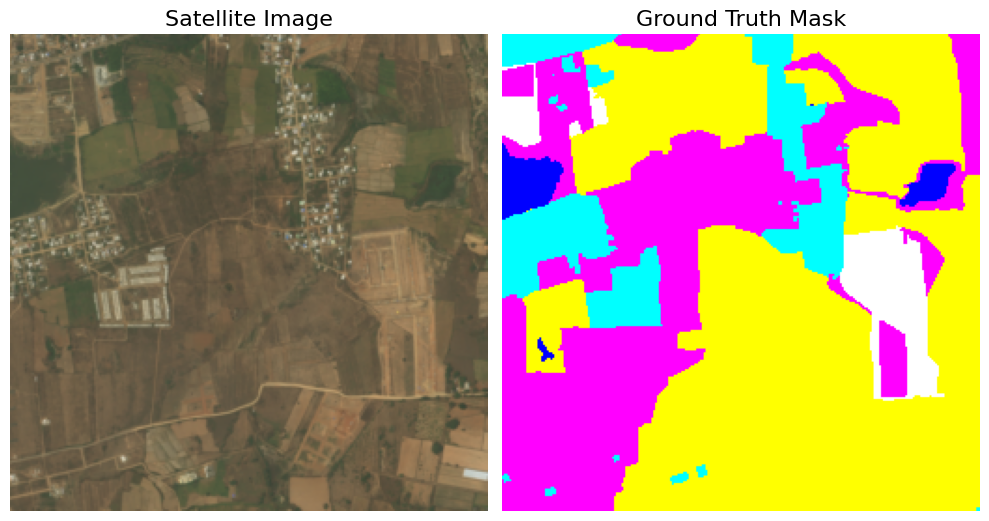

In [10]:
# Get the first image and mask from the training dataset
image, mask = train_dataset[0]

img_visualization = denormalize_image(image) 
mask_visualization = colour_code_segmentation(mask, class_rgb_values)
one_hot_encoded_mask = one_hot_encode(mask_visualization, class_rgb_values)
reverse_encoded_mask = reverse_one_hot(one_hot_encoded_mask)

visualize([('Satellite Image', img_visualization), ('Ground Truth Mask', mask_visualization)])

In [ ]:
# Count the class occurrences
class_counter = Counter()

for idx in range(len(train_df)):
    mask_path = train_df.loc[idx, 'mask_path']
    mask = Image.open(mask_path).convert('RGB')
    mask_np = np.array(mask)
    
    class_mask = rgb_to_class_mask(mask_np, class_rgb_values)
    class_counter.update(class_mask.flatten().tolist())

total = sum(class_counter.values())

class_weights = torch.tensor(
    [total / (class_counter[i] + 1e-8) for i in range(NUM_CLASSES)],
    dtype=torch.float32,
    device=device
)

# Save the weights to a .pth file
os.makedirs('output/', exist_ok=True)
torch.save(class_weights, 'output/class_weights.pth')

In [ ]:
# Load the class weights
class_weights = torch.load('output/class_weights.pth', map_location=device)

# Handle model outputs that may be in the form of a dictionary or a tensor
def get_model_output(model, images):
    outputs = model(images)
    if isinstance(outputs, dict):
        return outputs["out"]
    return outputs

# Efficient computation of IoU and F1 scores using a confusion matrix
def compute_iou_and_f1_confusion_matrix(confusion_matrix):
    true_positive = torch.diag(confusion_matrix).float()
    false_positive = confusion_matrix.sum(dim=0).float() - true_positive
    false_negative = confusion_matrix.sum(dim=1).float() - true_positive
    denom = true_positive + false_positive + false_negative + 1e-8 # Add a small epsilon to avoid division by zero

    iou = torch.where(denom > 0, true_positive / denom, torch.tensor(float('nan'))) # Compute IoU and handle cases where the denominator is zero
    miou = iou[~torch.isnan(iou)].mean().item() # Calculate mean IoU across all classes, ignoring NaN values

    f1 = torch.where(denom > 0, (2 * true_positive) / denom, torch.tensor(float('nan'))) # Compute F1 score and handle cases where the denominator is zero

    return iou.tolist(), miou, f1.tolist()

def update_confusion_matrix(confusion_matrix, predictions, targets):
    # Flatten the prediction and target tensors to 1D
    preds = predictions.view(-1).cpu()
    targets = targets.view(-1).cpu()

    valid_indices = (targets >= 0) & (targets < confusion_matrix.shape[0]) # Filter out invalid class indices
    index = NUM_CLASSES * targets[valid_indices] + preds[valid_indices] # Calculate the index for the confusion matrix

    confusion_matrix += torch.bincount(index, minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES) # Update the confusion matrix with the new counts
    return confusion_matrix

def function_train(model, train_loader, val_loader, num_epochs, model_name='model'):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    os.makedirs('output/checkpoints', exist_ok=True)

    best_val_miou = 0.0
    best_epoch = 0

    # Use ReduceLROnPlateau scheduler to reduce the learning rate when the validation mIoU plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {
        'train_loss': [], 'train_miou': [], 'train_per_class_iou': [], 'train_pixel_acc': [], 'train_f1': [],
        'val_loss':   [], 'val_miou':   [], 'val_per_class_iou':   [], 'val_pixel_acc':   [], 'val_f1': []
    }

    for epoch in range(num_epochs):
        model.train()

        train_loss = 0.0
        correct_pixels = 0
        total_pixels = 0

        confusion_matrix = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.long) # Initialize confusion matrix for the epoch

        # Iterate through the training data
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = get_model_output(model, images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step() 

            preds = torch.argmax(outputs, dim=1)
            train_loss += loss.item() * images.size(0)
            correct_pixels += (preds == masks).sum().item()
            total_pixels += masks.numel() # numel(): Returns the total number of elements in the tensor

            # Update the confusion matrix with the current batch of predictions and targets
            confusion_matrix = update_confusion_matrix(confusion_matrix, preds, masks)
    
        avg_train_loss = train_loss / len(train_loader.dataset)
        train_per_class_iou, train_miou, train_f1 = compute_iou_and_f1_confusion_matrix(confusion_matrix)
        train_pixel_acc = correct_pixels / (total_pixels + 1e-8)

        val_result = function_predict(model, val_loader, verbose=False)

        scheduler.step(val_result['miou']) # Step the scheduler based on the validation mIoU
        current_lr = optimizer.param_groups[0]['lr']

        if val_result['miou'] > best_val_miou:
            best_val_miou = val_result['miou']
            best_epoch = epoch + 1
            torch.save(model.state_dict(),
                       os.path.join('output/checkpoints', f'{model_name}_best.pth'))

        # Add the training and validation metrics to the history
        history['train_loss'].append(avg_train_loss)
        history['train_miou'].append(train_miou)
        history['train_per_class_iou'].append(train_per_class_iou)
        history['train_pixel_acc'].append(train_pixel_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_result['loss'])
        history['val_miou'].append(val_result['miou'])
        history['val_per_class_iou'].append(val_result['per_class_miou'])
        history['val_pixel_acc'].append(val_result['pixel_acc'])
        history['val_f1'].append(val_result['f1'])

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] - "
            f"Train Loss: {avg_train_loss:.4f}, Train mIoU: {train_miou:.4f}, Train Pixel Acc: {train_pixel_acc * 100:.2f}%, "
            f"Val Loss: {val_result['loss']:.4f}, Val mIoU: {val_result['miou']:.4f}, Val Pixel Acc: {val_result['pixel_acc'] * 100:.2f}%, "
        )
    
    os.makedirs('output/history', exist_ok=True)
    torch.save(history, os.path.join('output/history', f'{model_name}_train.pth'))

    print(f'\nBest checkpoint: epoch {best_epoch}  (Val mIoU = {best_val_miou:.4f})')
    print(f'Saved to: checkpoints/{model_name}_best.pth')

    return history

def function_predict(model, loader, model_name='model', verbose=False):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    running_loss = 0.0
    correct_pixels = 0
    total_pixels = 0

    confusion_matrix = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.long) # Initialize confusion matrix for evaluation

    # Iterate trough the data in the dataloader
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = get_model_output(model, images)
            loss = criterion(outputs, masks)
            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct_pixels += (preds == masks).sum().item()
            total_pixels += masks.numel() # numel(): Returns the total number of elements in the tensor

            # Update the confusion matrix with the current batch of predictions and targets
            confusion_matrix = update_confusion_matrix(confusion_matrix, preds, masks)

    avg_loss = running_loss / len(loader.dataset)
    per_class_miou, miou, f1 = compute_iou_and_f1_confusion_matrix(confusion_matrix)
    pixel_acc = correct_pixels / (total_pixels + 1e-8)

    # Print the values if verbose is set to true
    if verbose:
        print(f"Loss: {avg_loss:.4f}, mIoU: {miou:.4f}, Pixel Acc: {pixel_acc * 100:.2f}%")
        for class_index, class_iou in enumerate(per_class_miou):
            print(f"Class {class_index} IoU: {class_iou:.4f}")
    
    result = {
        'loss': avg_loss,
        'miou': miou,
        'per_class_miou': per_class_miou,
        'pixel_acc': pixel_acc,
        'f1': f1
    }
   
    os.makedirs('output/history', exist_ok=True)
    torch.save(result, os.path.join('output/history', f'{model_name}_test.pth')) # Save the results

    return result

def plot_history_result(history, model_name='model'):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_miou'], label='Train mIoU')
    plt.plot(epochs, history['val_miou'], label='Val mIoU')
    plt.title(f'{model_name} mIoU')
    plt.xlabel('Epochs')
    plt.ylabel('mIoU')
    plt.legend()

    plt.subplot(2, 2, 3)
    for class_index in range(NUM_CLASSES):
        train_per_class_iou = [per_class_iou[class_index] for per_class_iou in history['train_per_class_iou']]
        val_per_class_iou = [per_class_iou[class_index] for per_class_iou in history['val_per_class_iou']]
        plt.plot(epochs, train_per_class_iou, label=f'Train Class {class_index} IoU')
        plt.plot(epochs, val_per_class_iou, label=f'Val Class {class_index} IoU')
    
    plt.title(f'{model_name} Per-Class IoU')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, history['train_pixel_acc'], label='Train Pixel Acc')
    plt.plot(epochs, history['val_pixel_acc'], label='Val Pixel Acc')
    plt.title(f'{model_name} Pixel Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Pixel Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

def visualize_predictions(model, dataset, num_samples=1):
    model.eval()

    random.seed(42)
    indices = random.sample(range(len(dataset)), num_samples)

    with torch.no_grad():
        for index in indices:
            image, mask = dataset[index]
            image = image.unsqueeze(0).to(device) # Add batch dimension and move to device
            output = get_model_output(model, image)
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            img_visualization = denormalize_image(image.squeeze(0)) # Remove batch dimension for visualization
            mask_visualization = colour_code_segmentation(mask.cpu().numpy(), class_rgb_values)
            
            pred_mask_visualization = colour_code_segmentation(pred_mask, class_rgb_values)
            
            visualize([
                ('Satellite Image', img_visualization), 
                ('Ground Truth Mask', mask_visualization), 
                ('Predicted Mask', pred_mask_visualization)
            ])

Epoch [1/10] - Train Loss: 1.3870, Train mIoU: 0.2169, Train Pixel Acc: 40.86%, Val Loss: 1.4407, Val mIoU: 0.2731, Val Pixel Acc: 48.22%, 
Epoch [2/10] - Train Loss: 0.8866, Train mIoU: 0.3691, Train Pixel Acc: 64.10%, Val Loss: 1.0238, Val mIoU: 0.4131, Val Pixel Acc: 70.65%, 
Epoch [3/10] - Train Loss: 0.7569, Train mIoU: 0.4476, Train Pixel Acc: 71.34%, Val Loss: 0.9202, Val mIoU: 0.4642, Val Pixel Acc: 72.93%, 
Epoch [4/10] - Train Loss: 0.6803, Train mIoU: 0.4764, Train Pixel Acc: 73.20%, Val Loss: 0.9315, Val mIoU: 0.4671, Val Pixel Acc: 73.10%, 
Epoch [5/10] - Train Loss: 0.6016, Train mIoU: 0.5162, Train Pixel Acc: 76.71%, Val Loss: 0.8109, Val mIoU: 0.4946, Val Pixel Acc: 76.71%, 
Epoch [6/10] - Train Loss: 0.5487, Train mIoU: 0.5427, Train Pixel Acc: 77.75%, Val Loss: 0.8033, Val mIoU: 0.4967, Val Pixel Acc: 75.58%, 
Epoch [7/10] - Train Loss: 0.4985, Train mIoU: 0.5573, Train Pixel Acc: 78.76%, Val Loss: 0.7931, Val mIoU: 0.5034, Val Pixel Acc: 75.82%, 
Epoch [8/10] - Train

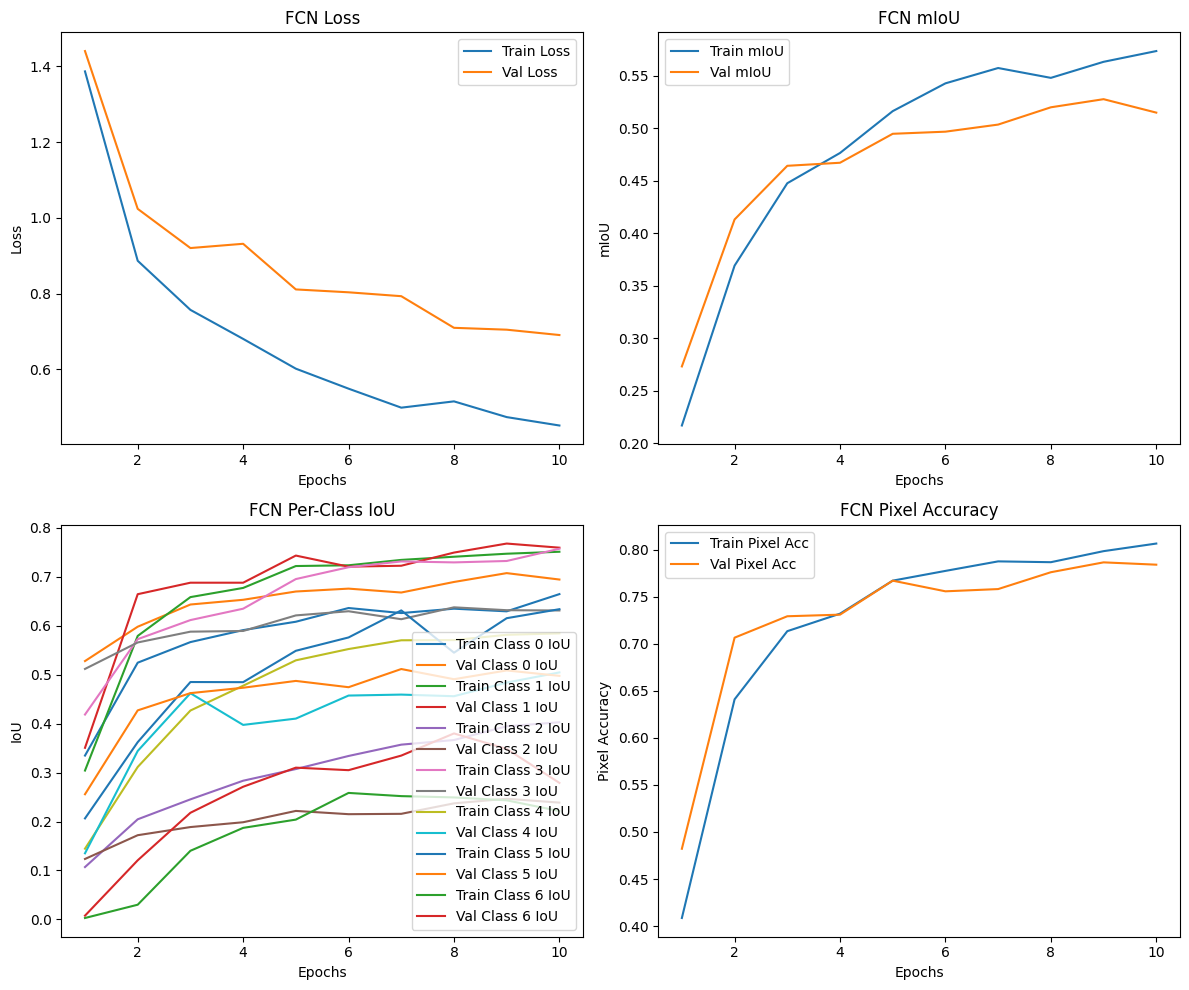

Loss: 0.7846, mIoU: 0.5041, Pixel Acc: 77.12%
Class 0 IoU: 0.6491
Class 1 IoU: 0.7446
Class 2 IoU: 0.2945
Class 3 IoU: 0.7271
Class 4 IoU: 0.4733
Class 5 IoU: 0.5358
Class 6 IoU: 0.1047


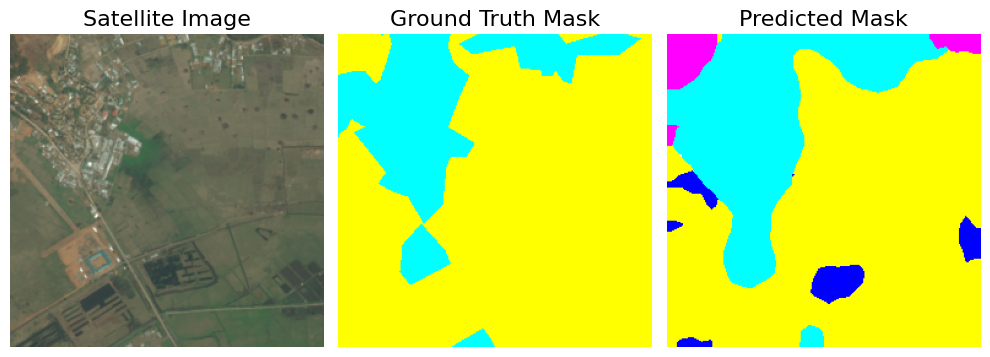

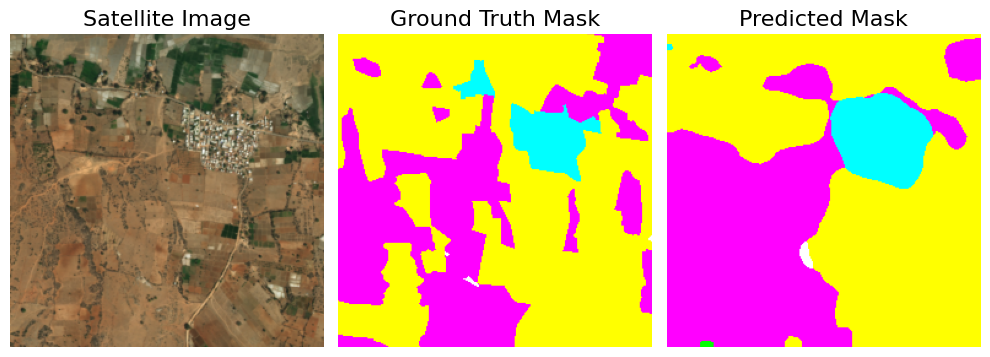

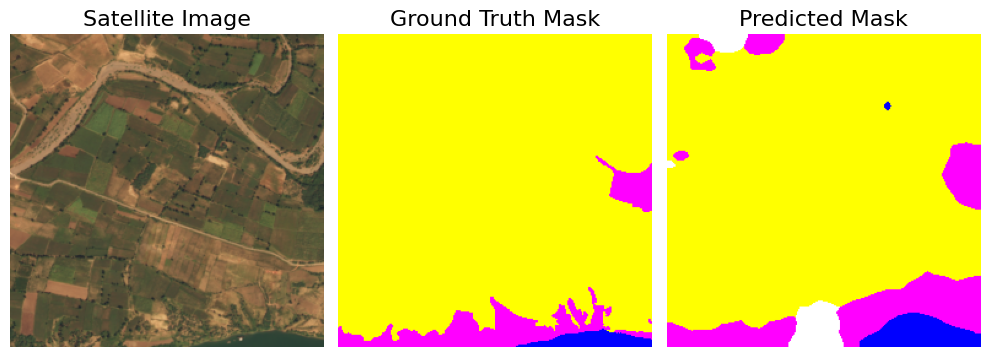

In [18]:
# Fully Convolutional Neural Network (FCN) with ResNet as backbone
fcn = segmentation.fcn_resnet50(
        weights=None,
        weights_backbone='DEFAULT',
        num_classes=NUM_CLASSES
    )
fcn.to(device)

fcn_train_history = function_train(fcn, train_loader, val_loader, NUM_EPOCHS, model_name='FCN')
plot_history_result(fcn_train_history, model_name='FCN')

fcn.load_state_dict(torch.load('output/checkpoints/FCN_best.pth')) # Load the best weights before evaluation
fcn_result_history = function_predict(fcn, test_loader, model_name='FCN', verbose=True)
visualize_predictions(fcn, test_dataset, num_samples=3)

In [ ]:
# U-Net
unet = smp.Unet(
    encoder_name='resnet34', 
    encoder_weights='imagenet', 
    in_channels=3, 
    classes=NUM_CLASSES
    )
unet.to(device)

unet_train_history = function_train(unet, train_loader, val_loader, NUM_EPOCHS, model_name='UNet')
plot_history_result(unet_train_history, model_name='UNet')

unet.load_state_dict(torch.load('output/checkpoints/UNet_best.pth')) # Load the best weights before evaluation
unet_result_history = function_predict(unet, test_loader, model_name='UNet', verbose=True)
visualize_predictions(unet, test_dataset, num_samples=3)

In [ ]:
# DeepLabV3+
deeplab = smp.DeepLabV3Plus(
    encoder_name='resnet50',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES
)
deeplab.to(device)

deeplab_train_history = function_train(deeplab, train_loader, val_loader, NUM_EPOCHS, model_name='DeepLabV3Plus')
plot_history_result(deeplab_train_history, model_name='DeepLab V3+')

deeplab.load_state_dict(torch.load('output/checkpoints/DeepLabV3Plus_best.pth')) # Load the best weights before evaluation
deeplab_test_result = function_predict(deeplab, test_loader, model_name='DeepLabV3Plus', verbose=True)
visualize_predictions(deeplab, test_dataset, num_samples=3)

In [ ]:
# PSPNet 
pspnet = smp.PSPNet(
    encoder_name='resnet50',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES
)
pspnet.to(device)

pspnet_train_history = function_train(pspnet, train_loader, val_loader, NUM_EPOCHS, model_name='PSPNet')
plot_history_result(pspnet_train_history, model_name='PSPNet')

pspnet.load_state_dict(torch.load('output/checkpoints/PSPNet_best.pth')) # Load the best weights before evaluation
pspnet_test_result = function_predict(pspnet, test_loader, model_name='PSPNet', verbose=True)
visualize_predictions(pspnet, test_dataset, num_samples=3)
    